- 미션 소개
    - 쇼핑몰 리뷰 데이터를 대상으로 감성 분석을 해 보는 미션입니다. 데이터 로드 및 전처리부터 모델 학습과 성능 평가까지 전부 구현하면 됩니다.
    - 모델을 학습시킬 때는 Full Fine-Tuning 방식과 PEFT 방식을 모두 활용해 보고 두 방식에 어떤 차이가 있는지 확인해 보세요. 예를 들어 모델을 학습시키는 데 걸리는 시간, 같은 조건으로 학습시켰을 때 감성 분석 정확도, 저장되는 모델 파일의 용량 등을 비교해 볼 수 있습니다.

- 사용 데이터셋
    - 먼저 이번 미션에 사용할 데이터 셋을 다운로드 받아주세요. (약 40MB)

    1. 데이터 형식:
        - JSON 파일 형태로 제공되는 리뷰 데이터입니다. JSON 파일 하나에 여러 개의 리뷰가 포함되어 있어요.

        - JSON 파일에서 리뷰 텍스트는 RawText에 있고, 리뷰에 대한 긍부정 라벨은 GeneralPolarity에 있습니다. GeneralPolarity 값은 -1일 때 부정, 0일 때 중립, 1일 때 긍정을 뜻합니다.

    2. 데이터 구성:

        - 패션, 화장품, 가전, IT기기, 생활 5가지 분야에 대해 쇼핑몰과 SNS에 달린 리뷰입니다. 원하는 분야의 리뷰를 선택하여 모델을 학습시키고 성능을 평가해 보세요.

- 가이드라인
    1. 데이터 로드 및 전처리
        - 리뷰 데이터를 로드하고, 감성 분석 모델을 학습시키기 위한 형식으로 적절하게 변환합니다.
        - 전체 데이터를 학습 데이터와 테스트 데이터로 분할합니다.
    2. Full Fine-Tuning 방식으로 모델 학습
        - Hugging Face의 transformers 라이브러리를 활용해 감성 분석 모델을 학습시킵니다.
    3. PEFT 방식으로 모델 학습
        - Hugging Face의 peft 라이브러리를 추가로 활용해 PEFT 방식으로 감성 분석 모델을 학습시킵니다.
    4. 두 가지 학습 방식 비교
        - Full Fine-Tuning 방식과 PEFT 방식의 학습 속도를 비교해 보세요.
        - 각 방식으로 학습시킨 모델 파일을 저장한 뒤 용량을 비교해 보세요.
        - 리뷰 텍스트의 실제 라벨과 모델이 예측한 결과를 비교하여 감성 분석 모델의 성능을 평가합니다. 두 가지 학습 방식 사이에 정확도 차이가 있는지 확인해 보세요.
    5. 마크다운 설명
        - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운 셀을 통해 간결하게 기록하세요.
        - 코드와 결과를 한눈에 이해할 수 있도록 전체 워크플로우를 체계적으로 정리해 주세요.
- 제출 안내
    - Colab Notebook 파일을 제출해 주세요.

    - 파일 이름은 13_{팀명}_{성함}.ipynb 형태로 작성해 주세요.

    1. 모델 구현 및 학습 결과
        - 주어진 데이터에 대한 감성 분석 모델을 구현해 주세요. 데이터 로드 → 전처리 → 모델 구축 및 학습 → 성능 평가 과정을 순차적으로 진행하세요.
    2. 마크다운을 활용한 설명
        - 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운을 통해 자세히 기록해 주세요.
        - 노트북 내에서 코드와 결과를 한눈에 이해할 수 있도록 정리해 주세요.
    3. Full Fine-Tuning과 PEFT 방식 비교 분석 및 제출
        - 두 가지 학습 방식에 어떤 차이가 있는지 비교 분석해 보고 그 결과를 정리해 주세요.
- 참고 사항
    - 미션을 시작할 때 도움이 필요하다면, Baseline 코드를 참고할 수 있습니다. 이 코드는 기본적인 코드로 제공되며, 여러분이 원하는 대로 자유롭게 변형할 수 있어요.
        - Baseline 코드 링크
        - 주의 사항: Baseline 코드는 여러분이 모델을 시작하는 데 도움을 주기 위한 참고 자료일 뿐이며, Baseline 코드를 그대로 사용하는 것보다는 이를 기반으로 자신의 아이디어를 추가하고 발전시키는 것이 중요합니다. 가능하면 스스로 모델을 구축해보고 다양한 방법을 시도하여 성능을 향상시켜 보세요.
    - 원본 데이터셋 링크
        - https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=71603

# 0.연구결과 및 결론

# requirements.txt

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# 모델 학습 전체 파이프라인을 Hugging Face 생태계 기준으로 완성하기 위한 필수 세트
!pip install -q datasets accelerate evaluate

In [3]:
!pip install --upgrade sympy

  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.13.3-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires sympy==1.13.1; python_version >= "3.9", but you have sympy 1.13.3 which is incompatible.


In [4]:
!pip install bitsandbytes

  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3


# 1.data

## data_utils.py

In [5]:
import os
import json
import pandas as pd

def get_df(data_dir):
    # json 파일 모으기
    json_paths = []
    for root, _, files in os.walk(data_dir):
        for file in files:
            if file.endswith(".json"):
                json_paths.append(os.path.join(root, file))

    # 제이슨 데이터에서 원하는 속성만 수집
    data = []
    for path in json_paths:
        with open(path, 'r', encoding='utf-8') as f:
            try:
                items = json.load(f)
                for item in items:
                    polarity = item.get("GeneralPolarity", None)
                    text = item.get("RawText", None)

                    if polarity is not None and text:  # 둘 다 있어야 추가
                        polarity = int(polarity)
                        if polarity in [-1, 0, 1]:
                            data.append({
                                "text": text,
                                "label": polarity + 1  # -1 → 0, 0 → 1, 1 → 2
                            })
            except Exception:
                continue  # 형식 이상한 파일은 무시하고 넘어감

    # 데이터프레임 만들기
    df = pd.DataFrame(data)
    df = df.dropna().drop_duplicates()
    return df

In [6]:
data_config = {
    # df
    "data_dir": "/content/drive/MyDrive/Colab Notebooks/25-1학기/25-17주차/review_data/쇼핑몰/05. 생활",     # 01. 패션/ 02. 화장품/ 03. 가전/ 04. IT기기/ 05. 생활

    # dataset
    "seed": 42,
    "test_size": 0.2,
    "val_size": 0.1,

    # tokenizer
    "model_name": "beomi/KcELECTRA-base",
    "max_length": 128,
    "input_column": "text",
    "label_column": "label",
    "text_output": True,    # True면 원문 포함
}

In [7]:
df = get_df(data_config["data_dir"])

### small EDA

In [8]:
df.head()

,text,label
0,잘받았습니다 감사해요. 바구니가 작긴 합니다 비좁은곳에 두기엔 갠찬은듯합니다,2
1,사이즈가 좀 작은 감이 있네요 빨래가 많이 담기질 않아서 빨래를 자주 해야할것 같습니다.,0
2,"조립하기도 쉽고, 생각보다 빨래도 많이 들어가서 좋아요~",2
3,빨래를 나눠담을 수 있어 편합니다. 무게가 가벼워서 흔들리긴 하지만 쓰는데 지장은 ...,1
4,다른 바구니는 옵션좀 넣으면 가격이 훌쩍 올라가는데 이상품은 그런거 없이 3단 바구...,1


In [9]:
df.describe()

,label
count,35724.000000
mean,1.559232
std,0.700388
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


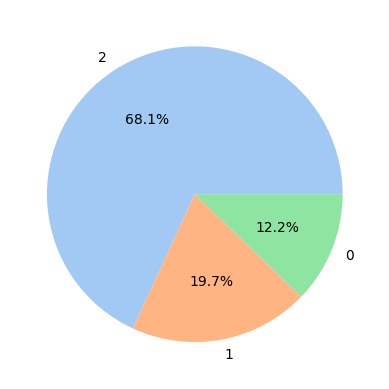

label
2    24337
1     7028
0     4359
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = sns.color_palette('pastel')[0:3]

plt.pie(df["label"].value_counts(), labels=df["label"].value_counts().index, autopct='%.1f%%', colors=colors)
plt.show()

print(df["label"].value_counts())

## loader.py

In [11]:
from datasets import Dataset

def get_datasets(df, config):
    # 전체 데이터셋
    dataset = Dataset.from_pandas(df)

    # 학습 시험 분리
    split_train_test = dataset.train_test_split(test_size=config["test_size"], seed=config["seed"])

    # 학습 검증 분리
    split_train_val = split_train_test['train'].train_test_split(test_size=config["val_size"], seed=config['seed'])

    datasets = {
        "train": split_train_val['train'],
        "val": split_train_val['test'],
        "test": split_train_test['test']
    }

    return datasets

In [12]:
datasets = get_datasets(df, data_config)

print(datasets)

{'train': Dataset({
    features: ['text', 'label'],
    num_rows: 25721
}), 'val': Dataset({
    features: ['text', 'label'],
    num_rows: 2858
}), 'test': Dataset({
    features: ['text', 'label'],
    num_rows: 7145
})}


In [13]:
from transformers import AutoTokenizer, BitsAndBytesConfig

def get_tokenizer(config):
    return AutoTokenizer.from_pretrained(config["model_name"])


def tokenize_datasets(datasets, tokenizer, config):
    def preprocess(example):
        tokenized = tokenizer(
            example[config["input_column"]],
            truncation=True,
            padding="max_length",
            max_length=config["max_length"]
        )
        if config.get("text_output"):
            tokenized["text"] = example[config["input_column"]]
        return tokenized

    tokenized_splits = {}
    for split in datasets:
        dataset = datasets[split]
        tokenized = dataset.map(preprocess, batched=True)
        tokenized = tokenized.rename_column(config["label_column"], "labels")
        tokenized.set_format(
            type="torch",
            columns=["input_ids", "attention_mask", "labels"] + (["text"] if config["text_output"] else [])
        )
        tokenized_splits[split] = tokenized

    return tokenized_splits

In [14]:
tokenizer = get_tokenizer(data_config)
tokenized_datasets = tokenize_datasets(datasets, tokenizer, data_config)

print(tokenized_datasets)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/25721 [00:00<?, ? examples/s]

Map:   0%|          | 0/2858 [00:00<?, ? examples/s]

Map:   0%|          | 0/7145 [00:00<?, ? examples/s]

{'train': Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 25721
}), 'val': Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2858
}), 'test': Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 7145
})}


In [15]:
tokenized_datasets["train"][0]

{'text': '세탁기 옆에 놨는데 사이즈 딱이네요 칸칸에 색대로 수건도 따로 분류해서 세탁하기 너무 편해졌습니다 진작 구입할걸 후회됩니다',
 'labels': tensor(2),
 'input_ids': tensor([17921,   290,  7220, 11775,   435,  2331,  2446,  1777,  3775,   534,
           119,  6787,   266,  3437,   780,   445,  8078,  3777, 16001,   606,
         14505,  1472,   977,  1395, 15081,   834,  5965,  7980, 11546,  5388,
          5889,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,     3,     3,     3,     3,     3,     3,     3,     3,     3,
             3,

# 2.train

In [25]:
from transformers import AutoModelForSequenceClassification
import torch
import cpufeature

# 4bit quatization
def get_quatization_config():
    if cpufeature.CPUFeature["AVX2"]:
        bnb_4bit_compute_dtype = torch.float32
    else:
        bnb_4bit_compute_dtype = torch.bfloat16

    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=bnb_4bit_compute_dtype
    )

from peft import get_peft_model, LoraConfig, TaskType

def get_model(config, peft_config=None):
    model = AutoModelForSequenceClassification.from_pretrained(
        config["model_name"],
        num_labels=3,  # 또는 len(set(df["label"]))
        # quantization_config=get_quatization_config(),     # cpu에서는 불가능
    )
    if peft_config:
        model = get_peft_model(model, peft_config)
    return model

In [26]:
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=2,
    lora_alpha=8,
    lora_dropout=0.05,
    target_modules=["query", "value"]
)

model_peft = get_model(data_config, peft_config)
model_peft.print_trainable_parameters()
print(model_peft)

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 666,627 || all params: 109,750,278 || trainable%: 0.6074
PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): ElectraForSequenceClassification(
      (electra): ElectraModel(
        (embeddings): ElectraEmbeddings(
          (word_embeddings): Embedding(30000, 768, padding_idx=3)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): ElectraEncoder(
          (layer): ModuleList(
            (0-11): 12 x ElectraLayer(
              (attention): ElectraAttention(
                (self): ElectraSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.05, inplace=False

In [29]:
import wandb
wandb.login()  # 터미널 또는 브라우저에서 API 키 입력

import os
os.environ["WANDB_PROJECT"] = "peft-classification"
os.environ["WANDB_LOG_MODEL"] = "end"

wandb.init(
    project="peft-classification",
)

In [30]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import torch

def get_training_args(config):
    return TrainingArguments(
        output_dir=config["output_dir"],
        per_device_train_batch_size=config["batch_size"],
        per_device_eval_batch_size=config["batch_size"],
        gradient_accumulation_steps=config.get("grad_accum", 2),
        num_train_epochs=config["num_epochs"],
        report_to="wandb",
        run_name=config["output_dir"].split("/")[-1],  # 디렉토리명 = 실험명

        # CPU 최적화를 위한 변경
        eval_strategy="steps",
        save_strategy="steps",
        eval_steps=config.get("eval_steps", 500),
        save_steps=config.get("save_steps", 500),
        logging_steps=config.get("logging_steps", 100),

        load_best_model_at_end=True,
        metric_for_best_model="accuracy",

        remove_unused_columns=False,
        dataloader_num_workers=0
    )

import numpy as np

def create_trainer(model, training_args, tokenized_datasets, mode='train'):
    accuracy_metric = evaluate.load("accuracy")
    precision_metric = evaluate.load("precision")
    recall_metric = evaluate.load("recall")
    f1_metric = evaluate.load("f1")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = torch.argmax(torch.tensor(logits), dim=1)

        acc = accuracy_metric.compute(predictions=preds, references=labels)
        prec = precision_metric.compute(predictions=preds, references=labels, average="macro")
        rec = recall_metric.compute(predictions=preds, references=labels, average="macro")
        f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")

        return {
            "accuracy": acc["accuracy"],
            "precision": prec["precision"],
            "recall": rec["recall"],
            "f1": f1["f1"],
        }
    if mode == 'train':
        return Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_datasets["train"],
            eval_dataset=tokenized_datasets["val"],
            compute_metrics=compute_metrics
        )
    elif mode == 'eval':
        return Trainer(
                model=model,
                args=training_args,
                compute_metrics=compute_metrics,
                eval_dataset=tokenized_datasets["test"]
        )
    else:
        raise ValueError

from datetime import datetime

def get_timestamped_output_dir(model_name, base_dir="./results"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    return f"{base_dir}/{model_name}_{timestamp}"

output_dir = get_timestamped_output_dir(data_config["model_name"])


trainer_config = {
    "num_epochs": 1,
    "batch_size": 2,
    "output_dir": output_dir,
    "eval_steps": 500,
    "save_steps": 500,
    "logging_steps": 500,
    "gradient_accumulation_steps": 4,
}

training_args = get_training_args(trainer_config)

trainer = create_trainer(model_peft, training_args, tokenized_datasets)
trainer.train()

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_predictions_and_labels(trainer, dataset):
    predictions = trainer.predict(dataset)
    pred_labels = torch.argmax(torch.tensor(predictions.predictions), dim=1)
    true_labels = predictions.label_ids

    return pred_labels, true_labels


def print_acc_and_confusion_matrix(true_labels, pred_labels):
    # 정확도
    test_accuracy = accuracy_score(true_labels, pred_labels)
    print(f"🎯 테스트 정확도: {test_accuracy * 100:.2f}%")

    # Confusion Matrix 출력
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "neutral", "positive"])
    disp.plot(cmap="Blues", values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
def print_samples(dataset, true_labels, pred_labels, num_samples=5):
    label_to_text = {0: "negative", 1: "neutral", 2: "positive"}

    # 정답/예측 샘플 출력
    print("\n✅ 예측 결과 샘플:")
    for i in range(num_samples):
        print("📝 원문:", dataset[i]["text"])
        print("✅ 실제:", label_to_text[dataset[i]["label"]], "🔮 예측:", label_to_text[pred_labels[i].item()])
        print("-" * 40)

    # 오분류된 샘플 출력
    print("\n\n❌ 예측이 틀린 샘플:")
    wrong_indices = [i for i, (pred, true) in enumerate(zip(pred_labels, true_labels)) if pred != true]
    for i in wrong_indices[:num_samples]:
        print("📝 원문:", dataset[i]["text"])
        print("✅ 실제:", label_to_text[dataset[i]["label"]], "🔮 예측:", label_to_text[pred_labels[i].item()])
        print("-" * 40)

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer
from peft import PeftModel, PeftConfig  # PEFT 사용 시

# 모델 불러오기
# model = AutoModelForSequenceClassification.from_pretrained("./results/checkpoint-1000")  # 일반 모델
# or PEFT 사용 시:
# peft_config = PeftConfig.from_pretrained("./results/checkpoint-1000")
# base_model = AutoModelForSequenceClassification.from_pretrained(peft_config.base_model_name_or_path)
# model = PeftModel.from_pretrained(base_model, "./results/checkpoint-1000")

# Trainer 재생성
eval_trainer = create_trainer(model_peft, training_args, tokenized_datasets, mode='eval')

# 평가 실행
pred_labels, true_labels = get_predictions_and_labels(eval_trainer, tokenized_datasets["test"])
print_acc_and_confusion_matrix(true_labels, pred_labels)
print_samples(datasets["test"], true_labels, pred_labels, num_samples=5)


✅ 예측 결과 샘플:
📝 원문: OOO과 맵만 같고 완전 다른 제품인데 가격은 비슷하다니 손해 봤어요ㅠㅠ. 운전하면서 작은 아이콘 눌러서 조작하다보면 정말 화가 절로 치미네요!  
✅ 실제: negative 🔮 예측: negative
----------------------------------------
📝 원문: 이 제품 업데이트가 안 되서 나중에 벽돌로 사용해야 하네요. 너무 아쉽네요. 그래서 엄청 복잡하게 검색해서 운영체제 다시 설치 했네요. 이 제품 너무 실망입니다.
✅ 실제: negative 🔮 예측: negative
----------------------------------------
📝 원문: 제품 로딩속도 빠릿빠릿하고 성능도 버벅거림 없어 만족해요~
✅ 실제: positive 🔮 예측: positive
----------------------------------------
📝 원문: 비슷한 스펙의 제품 중 가장 합리적인 가격이라 구매했어요! 다만 무게감이 조금 있어서 아쉽네요ㅠ
✅ 실제: neutral 🔮 예측: neutral
----------------------------------------
📝 원문: 귀에 착 감겨서 착용 시 불편한 게 없어요^-^ 통화 음질도 선명한 편이라 넘 좋은데요!!
✅ 실제: positive 🔮 예측: positive
----------------------------------------


❌ 예측이 틀린 샘플:
📝 원문: 음질 부드럽고 선명해서 좋아요 사이즈가 작아서 귀엽긴한데 너무 작아서 잃어 버릴까봐 걱정되요
✅ 실제: positive 🔮 예측: neutral
----------------------------------------
📝 원문: 이어폰의 사이즈가 생각보다 커서 당황했네요. 음질도 그냥저냥 들을만 해요. 커널형이라 귀에 착용감은 좋습니다.
✅ 실제: neutral 🔮 예측: positive
----------------------------------------
📝 원문: 외관 맘에